In [1]:
import pandas as pd

In [ ]:
df = pd.read_excel("mf_data.xlsx")

In [3]:
df

,Sl.No.,Clientid,BO_MFClientID,DOB,InvestType,Paymentmode,FundType,MFNo,MFInvestment,Tenure,TenureInDays,Gender,ADDITIONALPRODUCTSPURCHASED,RSM ID,BOClientid,DPID,DPClientid
0,1.0,ACC0010583,239064,1955-06-02 00:00:00.000,SIP,CHEQUE,ONGOING,1,8.136612e+05,108943,108943,M,Y,425.0,0,Unknown,0
1,2.0,ACC0010722,100570,1955-10-16 00:00:00.000,LUMSUM,CHEQUE,NFO,7,5.830323e+05,190864,27266,F,Y,NaN,0,Unknown,0
2,3.0,ACC0011095,28585,1968-01-10 00:00:00.000,SIP,CHEQUE,ONGOING,9,1.772156e+06,380451,42272,M,Y,333.0,0,Unknown,0
3,4.0,ACC0011613,9941,1959-12-10 00:00:00.000,SIP,CHEQUE,ONGOING,41,1.422040e+07,2503198,61053,M,N,333.0,0,Unknown,0
4,5.0,ACC0011801,34799,1899-12-30 00:00:00.000,SIP,CHEQUE,ONGOING,4,4.148992e+05,8204,2051,M,Y,543.0,0,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144211,NaN,ACC1075215,14418,1966-05-08 00:00:00.000,LUMSUM,CHEQUE,CLOSED,1,1.516110e+06,66985,66985,M,N,NaN,0,Unknown,0
144212,NaN,ACC1041029,171274,1956-04-08 00:00:00.000,SIP,CHEQUE,CLOSED,1,3.577371e+04,6480,6480,M,Y,423.0,1290082314,IN301637,40178480
144213,NaN,ACC2616006,196554,1986-01-31 00:00:00.000,SIP,CHEQUE,CLOSED,1,4.852695e+05,51853,51853,M,N,333.0,0,Unknown,0
144214,NaN,ACC2827552,552672,1984-08-26 00:00:00.000,SIP,CHEQUE,CLOSED,1,5.573001e+05,35113,35113,M,N,333.0,0,Unknown,0


In [4]:
df = df.drop(['Sl.No.','Clientid','BO_MFClientID','BOClientid', 'DPID', 'DPClientid'], axis=1)

In [5]:
df.columns

Index(['DOB', 'InvestType', 'Paymentmode', 'FundType', 'MFNo', 'MFInvestment',
       'Tenure', 'TenureInDays', 'Gender', 'ADDITIONALPRODUCTSPURCHASED',
       'RSM ID'],
      dtype='object')

In [6]:
df.shape

(144216, 11)

In [7]:
df.describe()

,MFNo,MFInvestment,Tenure,TenureInDays,RSM ID
count,144216.000000,1.442160e+05,1.442160e+05,1.442160e+05,110588.000000
mean,3.011566,5.728889e+05,1.266238e+05,4.256446e+04,327.849134
std,3.644846,2.283801e+06,2.866593e+05,7.970599e+04,95.750145
min,1.000000,0.000000e+00,-2.100000e+01,-2.100000e+01,111.000000
25%,1.000000,2.274886e+04,2.475000e+03,1.455000e+03,333.000000
50%,2.000000,1.137134e+05,3.212050e+04,1.515100e+04,333.000000
75%,3.000000,4.498138e+05,1.385548e+05,7.075000e+04,333.000000
max,142.000000,2.849732e+08,2.060583e+07,1.316258e+07,555.000000


In [8]:
df.isnull().sum()

,0
DOB,0
InvestType,0
Paymentmode,0
FundType,6
MFNo,0
MFInvestment,0
Tenure,0
TenureInDays,0
Gender,0
ADDITIONALPRODUCTSPURCHASED,0


In [9]:
df["Churn"] = df["FundType"].apply(lambda x: 1 if x == "CLOSED" else 0)

In [10]:
df['RSM ID'].fillna(000.0, inplace=True)

<ipython-input-10-b68f4be04d09>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RSM ID'].fillna(000.0, inplace=True)


In [11]:
df.isnull().sum()

,0
DOB,0
InvestType,0
Paymentmode,0
FundType,6
MFNo,0
MFInvestment,0
Tenure,0
TenureInDays,0
Gender,0
ADDITIONALPRODUCTSPURCHASED,0


In [12]:
#SEPERATE RFM INTO R F M
df['R'] = df['RSM ID'].astype(str).str[0]
df['S'] = df['RSM ID'].astype(str).str[1]
df['M'] = df['RSM ID'].astype(str).str[2]

In [13]:
from datetime import datetime

# Calculate age
current_date = datetime(2025, 3, 4)

# Ensure 'DOB' column is of datetime type before calculation
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')  # Convert to datetime, handling errors

# Calculate age only for valid datetime values
df['age'] = df['DOB'].apply(lambda dob: (current_date - dob).days // 365.25 if pd.notnull(dob) else -1)

# Convert age to integers
df['age'] = df['age'].astype(int)

In [14]:
df['age']

,age
0,69
1,69
2,57
3,65
4,125
...,...
144211,58
144212,68
144213,39
144214,40


In [15]:
# 1. **TENURE CATEGORY** = Short-term (<3 years), Mid-term (3-7 years), Long-term (>7 years)
df["TenuryCategory"] = pd.cut(df["Tenure"], bins=[0, 1095, 2555, df["Tenure"].max()], labels=["Short-term", "Mid-term", "Long-term"])

# 2. **INVESTMENT FREQUENCY** = SIP monthly investment, Lump Sum remains unchanged
df["INVESTMENT FREQUENCY"] = df.apply(lambda x: x["MFInvestment"] / (x["Tenure"] if x["Tenure"] > 0 and x["InvestType"] == "SIP" else 1), axis=1)

# 3. **DIVERSIFICATION SCORE** = Number of mutual funds divided by total investment
df["DIVERSIFICATION SCORE"] = df.apply(lambda x: x["MFNo"] / x["MFInvestment"] if x["MFInvestment"] > 0 else 0, axis=1)

In [16]:
df.columns

Index(['DOB', 'InvestType', 'Paymentmode', 'FundType', 'MFNo', 'MFInvestment',
       'Tenure', 'TenureInDays', 'Gender', 'ADDITIONALPRODUCTSPURCHASED',
       'RSM ID', 'Churn', 'R', 'S', 'M', 'age', 'TenuryCategory',
       'INVESTMENT FREQUENCY', 'DIVERSIFICATION SCORE'],
      dtype='object')

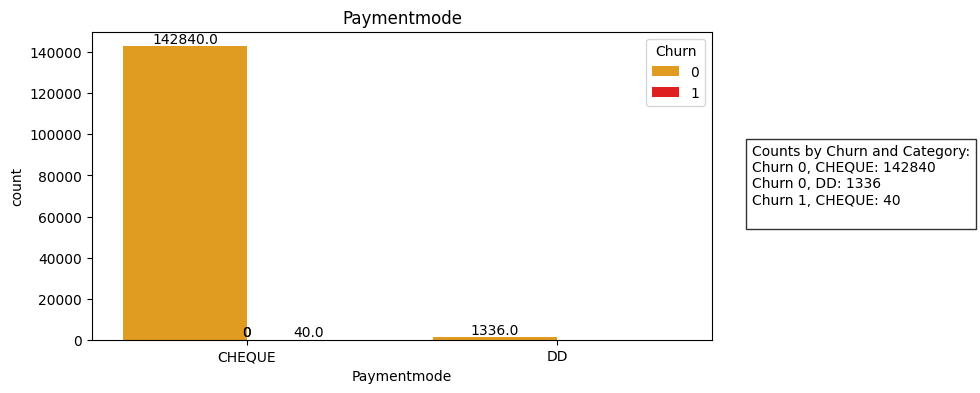

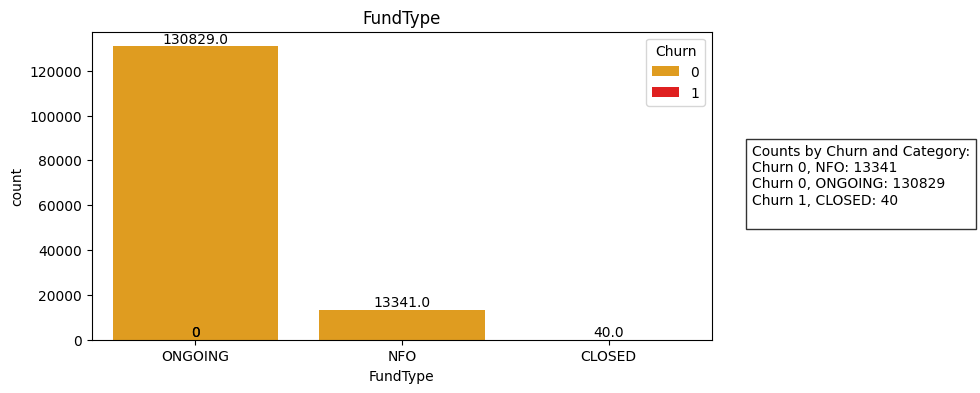

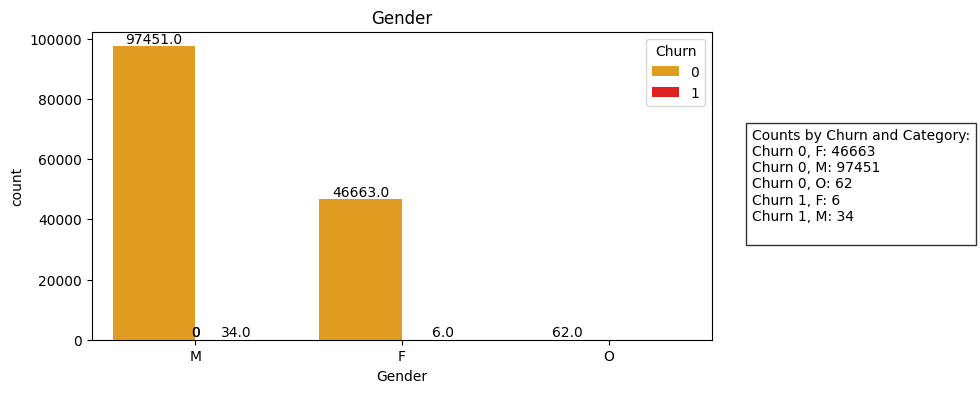

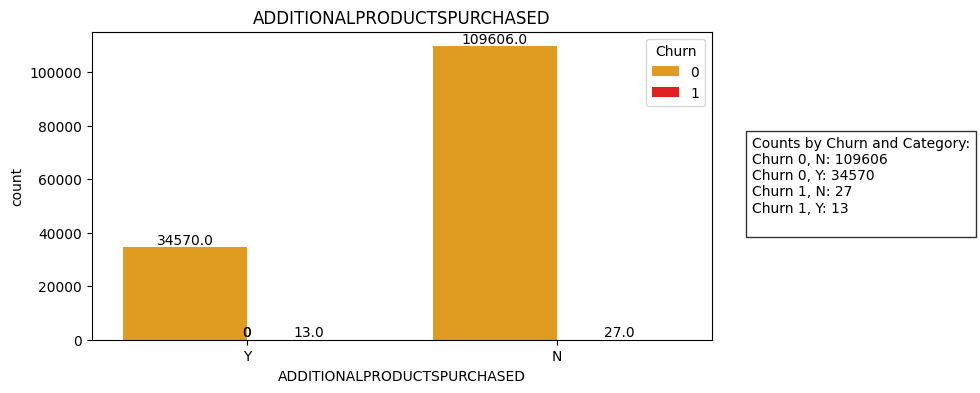

<ipython-input-17-b25051f4aeba>:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_counts = df.groupby(['Churn', predictor]).size().reset_index(name='counts')


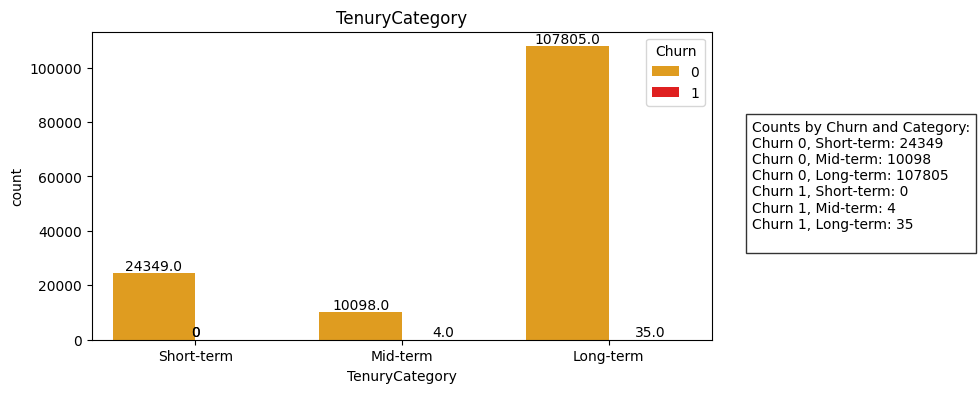

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

palette = {0: 'orange', 1: 'red'}

for i, predictor in enumerate(df.drop(columns=['DOB','InvestType','MFInvestment','MFNo','RSM ID',
                                              'Tenure','TenureInDays','Churn','R','S','M','INVESTMENT FREQUENCY', 'DIVERSIFICATION SCORE','age'])):
    plt.figure(i, figsize=(8, 4))
    ax = sns.countplot(data=df, x=predictor, hue='Churn', palette=palette)
    plt.title(predictor)

    # Add count labels on top of bars (same as before)
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

    # Calculate counts for each churn group and category
    churn_counts = df.groupby(['Churn', predictor]).size().reset_index(name='counts')

    # Create text for the details box
    details_text = "Counts by Churn and Category:\n"
    for index, row in churn_counts.iterrows():
        details_text += f"Churn {row['Churn']}, {row[predictor]}: {row['counts']}\n"

    # Position the details box
    plt.figtext(0.95, 0.5, details_text, ha='left', va='center', bbox=dict(facecolor='white', alpha=0.8))

    plt.show()

In [18]:
df.head()

,DOB,InvestType,Paymentmode,FundType,MFNo,MFInvestment,Tenure,TenureInDays,Gender,ADDITIONALPRODUCTSPURCHASED,RSM ID,Churn,R,S,M,age,TenuryCategory,INVESTMENT FREQUENCY,DIVERSIFICATION SCORE
0,1955-06-02,SIP,CHEQUE,ONGOING,1,8.136612e+05,108943,108943,M,Y,425.0,0,4,2,5,69,Long-term,7.468687,0.000001
1,1955-10-16,LUMSUM,CHEQUE,NFO,7,5.830323e+05,190864,27266,F,Y,0.0,0,0,.,0,69,Long-term,583032.262400,0.000012
2,1968-01-10,SIP,CHEQUE,ONGOING,9,1.772156e+06,380451,42272,M,Y,333.0,0,3,3,3,57,Long-term,4.658040,0.000005
3,1959-12-10,SIP,CHEQUE,ONGOING,41,1.422040e+07,2503198,61053,M,N,333.0,0,3,3,3,65,Long-term,5.680893,0.000003
4,1899-12-30,SIP,CHEQUE,ONGOING,4,4.148992e+05,8204,2051,M,Y,543.0,0,5,4,3,125,Long-term,50.572788,0.000010


In [19]:
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

# Or if you are using > Python 3.11:
with warnings.catch_warnings(action="ignore"):
    fxn()

In [20]:
df['TenuryCategory'].value_counts()

,count
TenuryCategory,
Long-term,107840
Short-term,24349
Mid-term,10102


In [21]:
# Visualization
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

Text(0, 0.5, 'Investment')

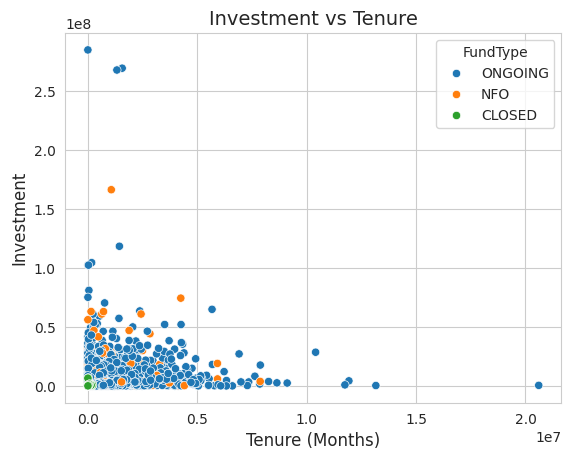

In [22]:
# Investment vs Tenure
sns.scatterplot(x=df['Tenure'], y=df['MFInvestment'], hue=df['FundType'])
plt.title('Investment vs Tenure', fontsize=14)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Investment', fontsize=12)

Text(0, 0.5, 'Investment')

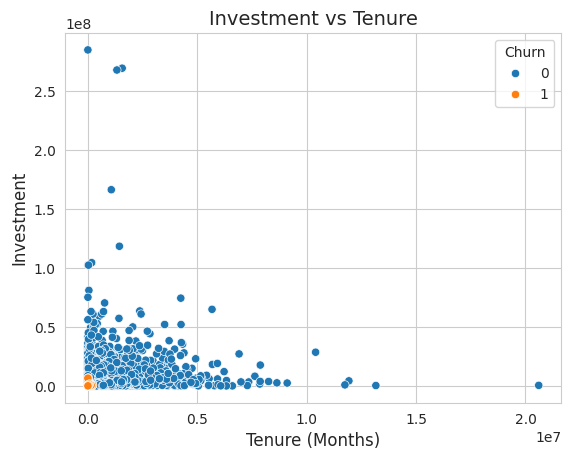

In [23]:
sns.scatterplot(x=df['Tenure'], y=df['MFInvestment'], hue=df['Churn'])
plt.title('Investment vs Tenure', fontsize=14)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Investment', fontsize=12)

<ipython-input-24-257732ffc3e5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='InvestType', data=df, palette='pastel')


Text(0, 0.5, 'Count')

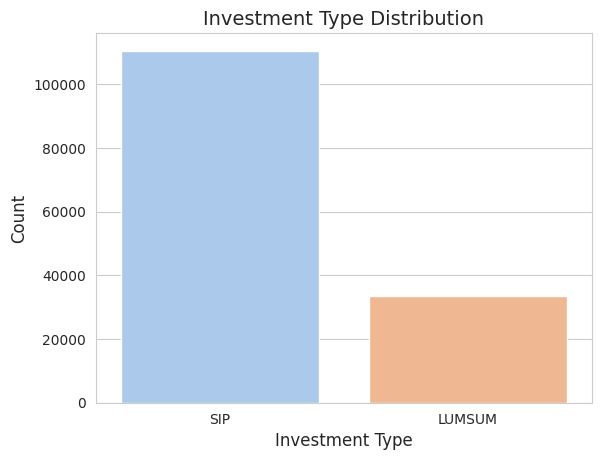

In [24]:
# Investment Type Countplot
sns.countplot(x='InvestType', data=df, palette='pastel')
plt.title('Investment Type Distribution', fontsize=14)
plt.xlabel('Investment Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

<ipython-input-25-3b4a7e9b17e6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Paymentmode', data=df, palette='Set2')


Text(0, 0.5, 'Count')

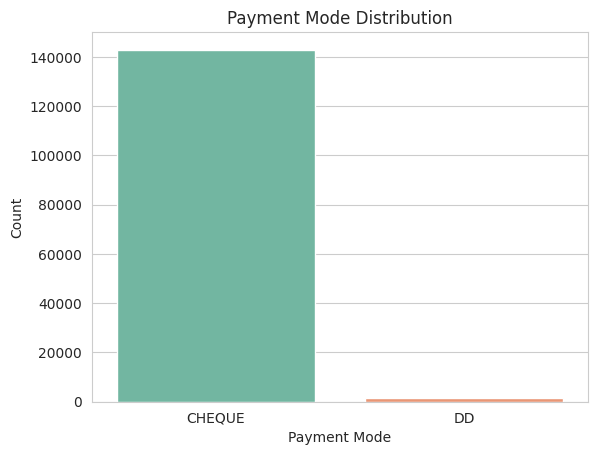

In [25]:
# Payment Mode Distribution
sns.countplot(x='Paymentmode', data=df, palette='Set2')
plt.title('Payment Mode Distribution')
plt.xlabel('Payment Mode')
plt.ylabel('Count')

<ipython-input-26-c6554b1f1df2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ADDITIONALPRODUCTSPURCHASED', data=df, palette='Set1')


Text(0, 0.5, 'Count')

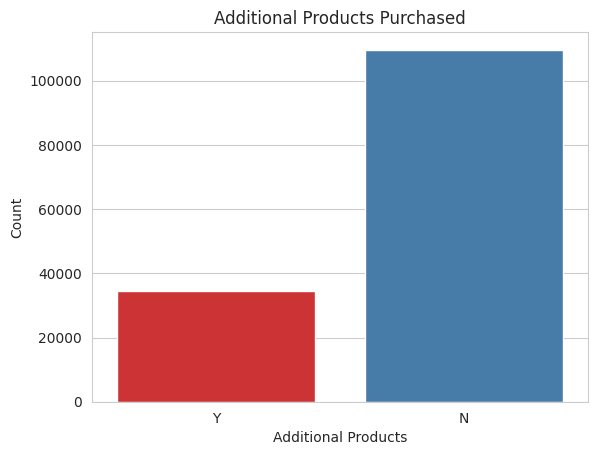

In [26]:
# Additional Products Purchased
sns.countplot(x='ADDITIONALPRODUCTSPURCHASED', data=df, palette='Set1')
plt.title('Additional Products Purchased')
plt.xlabel('Additional Products')
plt.ylabel('Count')

In [27]:
df['Churn'].value_counts()

,count
Churn,
0,144176
1,40


In [28]:
for col in df.columns:
    print(f"Unique values in {col}: {df[col].unique()}\n")

Unique values in DOB: <DatetimeArray>
['1955-06-02 00:00:00', '1955-10-16 00:00:00', '1968-01-10 00:00:00',
 '1959-12-10 00:00:00', '1899-12-30 00:00:00', '1964-04-11 00:00:00',
 '1972-12-04 00:00:00', '1976-05-16 00:00:00', '1970-08-15 00:00:00',
 '1948-08-10 00:00:00',
 ...
 '2009-07-17 00:00:00', '1947-08-05 00:00:00', '1950-03-21 00:00:00',
 '1949-02-22 00:00:00', '1950-06-18 00:00:00', '1951-09-19 00:00:00',
 '2002-06-28 00:00:00', '1948-05-04 00:00:00', '1943-01-13 00:00:00',
 '1941-09-21 00:00:00']
Length: 24113, dtype: datetime64[ns]

Unique values in InvestType: ['SIP' 'LUMSUM']

Unique values in Paymentmode: ['CHEQUE' 'DD']

Unique values in FundType: ['ONGOING' 'NFO' nan 'CLOSED']

Unique values in MFNo: [  1   7   9  41   4  18   8   5  12  10   3  11   2   6  13  14  30  31
  21  15  17  22  29  20  19  35  26  51  24  25  32  16  34  23  27  57
  46  28  55  38  52  68  37  62  40  33  79  43  61  44  48  50  39  96
  36  76  60  42  45  71  67  47  72  54  66  69 142  85

In [29]:
df=df.drop(['DOB','FundType'],axis=1)

In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder

In [31]:
object_cols = df.select_dtypes(include=['object']).columns

# Create a OneHotEncoder object
enc = OneHotEncoder(handle_unknown='ignore')
encoded_data = enc.fit_transform(df[object_cols]).toarray()
encoded_col_names = enc.get_feature_names_out(object_cols)
encoded_df = pd.DataFrame(encoded_data, columns=encoded_col_names)
df = pd.concat([df.drop(object_cols, axis=1), encoded_df], axis=1)

In [32]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['TenuryCategory'] = label_encoder.fit_transform(df['TenuryCategory'])

In [33]:
X = df.drop(columns=['Churn'])
y = df['Churn']

                       MFInvestment    Tenure       age      MFNo  \
MFInvestment               1.000000  0.333041  0.094936  0.407853   
Tenure                     0.333041  1.000000  0.095027  0.503824   
age                        0.094936  0.095027  1.000000  0.119902   
MFNo                       0.407853  0.503824  0.119902  1.000000   
INVESTMENT FREQUENCY       0.784654  0.130489  0.076301  0.256464   
DIVERSIFICATION SCORE     -0.013145 -0.005806  0.044354 -0.028596   

                       INVESTMENT FREQUENCY  DIVERSIFICATION SCORE  
MFInvestment                       0.784654              -0.013145  
Tenure                             0.130489              -0.005806  
age                                0.076301               0.044354  
MFNo                               0.256464              -0.028596  
INVESTMENT FREQUENCY               1.000000              -0.006447  
DIVERSIFICATION SCORE             -0.006447               1.000000  


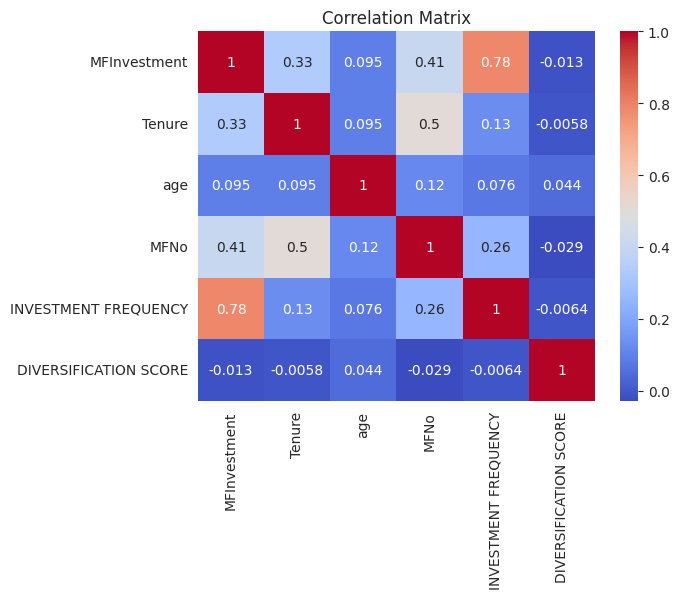

In [34]:
# prompt: create a correaltion matrix using basic featues only

import matplotlib.pyplot as plt
correlation_matrix = df[['MFInvestment', 'Tenure', 'age', 'MFNo', 'INVESTMENT FREQUENCY', 'DIVERSIFICATION SCORE']].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [35]:

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [36]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy= 0.9,random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

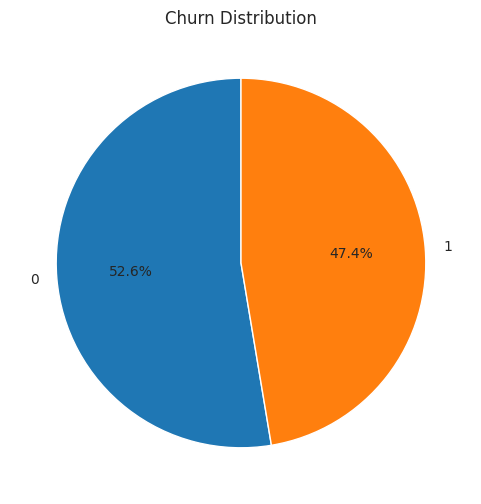

In [39]:
plt.figure(figsize=(6, 6))
pd.Series(y_train).value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90) # Convert y_train_resampled to Series and specify labels
plt.title('Churn Distribution')
plt.ylabel('')  # Remove the y-axis label
plt.show()

In [40]:
y_train.value_counts()

,count
Churn,
0,115340
1,103806


In [41]:
X_train.shape

(219146, 36)

In [42]:
import numpy as np

In [43]:
# Create and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators = 100, oob_score = True,n_jobs = 1,random_state =42,
                                       max_features='sqrt',max_depth=6,max_leaf_nodes=6)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[26934  1902]
 [    3     5]]

Accuracy: 0.9339550686451255

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97     28836
           1       0.00      0.62      0.01         8

    accuracy                           0.93     28844
   macro avg       0.50      0.78      0.49     28844
weighted avg       1.00      0.93      0.97     28844



In [44]:
# Create and train the XGBClassifier
xgb_classifier = XGBClassifier(random_state=42,learning_rate =0.01,n_estimators=100,max_depth=5,
                                min_child_weight=1,gamma=1,subsample=0.5,colsample_bytree=0.5,
                                objective= 'binary:logistic',nthread=4,scale_pos_weight=1,seed=27)
xgb_classifier.fit(X_train, y_train)


# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:\n", cm_xgb)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Accuracy: {accuracy_xgb}")

print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Confusion Matrix:
 [[27589  1247]
 [    3     5]]

XGBoost Accuracy: 0.9566634308695049

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     28836
           1       0.00      0.62      0.01         8

    accuracy                           0.96     28844
   macro avg       0.50      0.79      0.49     28844
weighted avg       1.00      0.96      0.98     28844



In [45]:
log_reg_classifier = LogisticRegression(random_state=42)
log_reg_classifier.fit(X_train, y_train)

imputer = SimpleImputer(strategy='mean')  # Or use other strategies like 'median', 'most_frequent'
X_test = imputer.fit_transform(X_test)

# Make predictions on the test set
y_pred_logreg = log_reg_classifier.predict(X_test)

# Evaluate the model
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Logistic Regression Confusion Matrix:\n", cm_logreg)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"\nLogistic Regression Accuracy: {accuracy_logreg}")

print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_logreg))


Logistic Regression Confusion Matrix:
 [[25537  3299]
 [    3     5]]

Logistic Regression Accuracy: 0.8855221189848842

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94     28836
           1       0.00      0.62      0.00         8

    accuracy                           0.89     28844
   macro avg       0.50      0.76      0.47     28844
weighted avg       1.00      0.89      0.94     28844



In [46]:
from sklearn.naive_bayes import GaussianNB

# Create and train the Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_classifier.predict(X_test)

# Evaluate the model
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Naive Bayes Confusion Matrix:\n", cm_nb)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nNaive Bayes Accuracy: {accuracy_nb}")

print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Confusion Matrix:
 [[18108 10728]
 [    0     8]]

Naive Bayes Accuracy: 0.628068229094439

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.63      0.77     28836
           1       0.00      1.00      0.00         8

    accuracy                           0.63     28844
   macro avg       0.50      0.81      0.39     28844
weighted avg       1.00      0.63      0.77     28844



In [47]:
from sklearn.tree import DecisionTreeClassifier

# Create and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42,criterion='entropy', splitter='random', min_samples_split=2,
                                       min_samples_leaf=1,max_leaf_nodes=12)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the model
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:\n", cm_dt)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Accuracy: {accuracy_dt}")

print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Confusion Matrix:
 [[26327  2509]
 [    3     5]]

Decision Tree Accuracy: 0.912910830675357

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     28836
           1       0.00      0.62      0.00         8

    accuracy                           0.91     28844
   macro avg       0.50      0.77      0.48     28844
weighted avg       1.00      0.91      0.95     28844



In [48]:

import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# Create and train the LightGBM classifier
lgb_classifier = lgb.LGBMClassifier(random_state=42,learning_rate=0.01,max_depth=-5)
lgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgb = lgb_classifier.predict(X_test)

# Evaluate the model
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
print("LightGBM Confusion Matrix:\n", cm_lgb)

accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"\nLightGBM Accuracy: {accuracy_lgb}")

print("\nLightGBM Classification Report:\n", classification_report(y_test, y_pred_lgb))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 103806, number of negative: 115340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6702
[LightGBM] [Info] Number of data points in the train set: 219146, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473684 -> initscore=-0.105361
[LightGBM] [Info] Start training from score -0.105361
LightGBM Confusion Matrix:
 [[27933   903]
 [    5     3]]

LightGBM Accuracy: 0.9685203161836083

LightGBM Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     28836
           1       0.00      0.38      0.01         8

    accuracy                           0.97     28844
   macro avg       0.50      0.67      0.50     28844
weighted avg       1.00      0.97  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


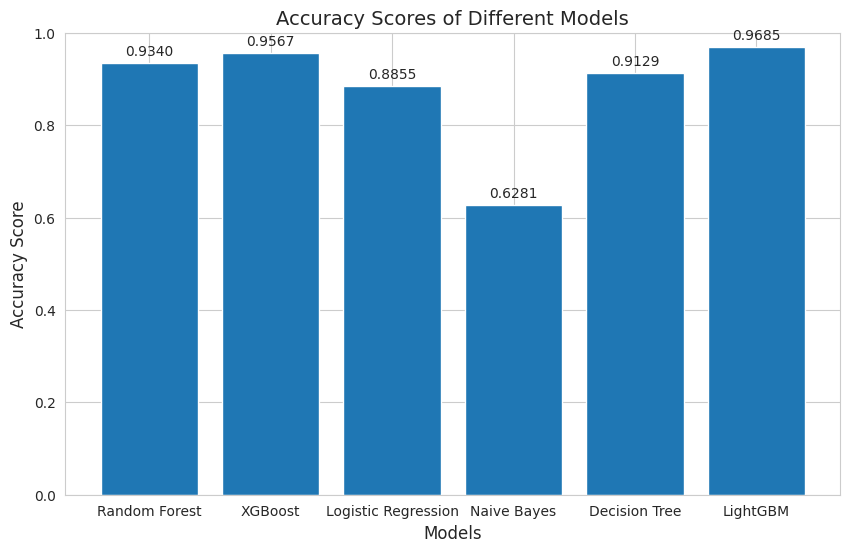

In [49]:
# Accuracy scores for each model
accuracy_scores = {
    'Random Forest': accuracy,
    'XGBoost': accuracy_xgb,
    'Logistic Regression': accuracy_logreg,
    'Naive Bayes': accuracy_nb,
    'Decision Tree': accuracy_dt,
    'LightGBM': accuracy_lgb,
}

# Extract model names and accuracy scores
models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(models, scores)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.title("Accuracy Scores of Different Models", fontsize=14)

# Add labels on top of each bar
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.show()


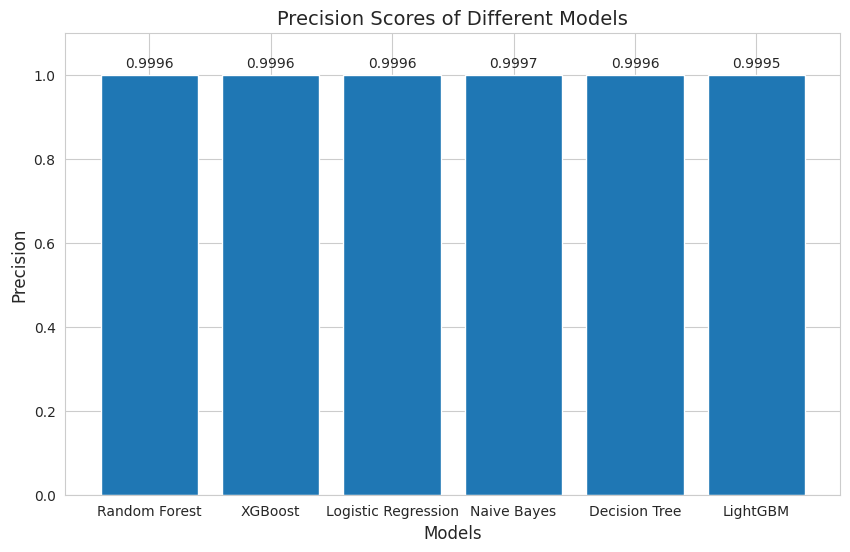

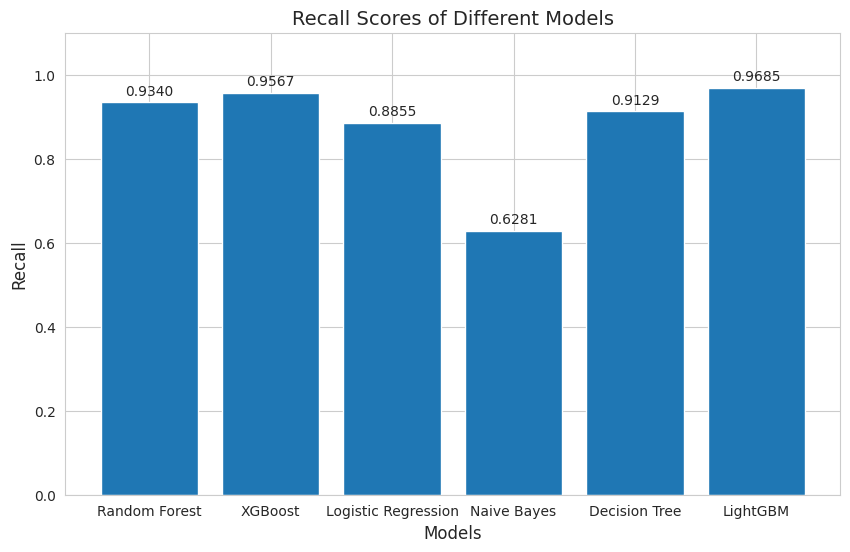

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# ... (Your existing code) ...

# Calculate precision and recall for each model
precision_recall_rf = precision_recall_fscore_support(y_test, y_pred, average='weighted')
precision_recall_xgb = precision_recall_fscore_support(y_test, y_pred_xgb, average='weighted')
precision_recall_logreg = precision_recall_fscore_support(y_test, y_pred_logreg, average='weighted')
precision_recall_nb = precision_recall_fscore_support(y_test, y_pred_nb, average='weighted')
precision_recall_dt = precision_recall_fscore_support(y_test, y_pred_dt, average='weighted')
precision_recall_lgb = precision_recall_fscore_support(y_test, y_pred_lgb, average='weighted')


precision_scores = {
    'Random Forest': precision_recall_rf[0],
    'XGBoost': precision_recall_xgb[0],
    'Logistic Regression': precision_recall_logreg[0],
    'Naive Bayes': precision_recall_nb[0],
    'Decision Tree': precision_recall_dt[0],
    'LightGBM': precision_recall_lgb[0],
}

recall_scores = {
    'Random Forest': precision_recall_rf[1],
    'XGBoost': precision_recall_xgb[1],
    'Logistic Regression': precision_recall_logreg[1],
    'Naive Bayes': precision_recall_nb[1],
    'Decision Tree': precision_recall_dt[1],
    'LightGBM': precision_recall_lgb[1],
}

# Plotting Precision
models = list(precision_scores.keys())
precisions = list(precision_scores.values())

plt.figure(figsize=(10, 6))
plt.bar(models, precisions)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision Scores of Different Models", fontsize=14)
for i, v in enumerate(precisions):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1.1)  # Adjust y-axis limit if needed
plt.show()

# Plotting Recall
models = list(recall_scores.keys())
recalls = list(recall_scores.values())

plt.figure(figsize=(10, 6))
plt.bar(models, recalls)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Recall", fontsize=12)
plt.title("Recall Scores of Different Models", fontsize=14)
for i, v in enumerate(recalls):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1.1)  # Adjust y-axis limit if needed
plt.show()

In [51]:
import numpy as np

from sklearn.model_selection import KFold, cross_val_score

def perform_kfold_cv(model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    return cv_scores

# Models to evaluate
models = {
    'Random Forest': rf_classifier,
    'XGBoost': xgb_classifier,
    'Logistic Regression': log_reg_classifier,
    'Naive Bayes': nb_classifier,
    'Decision Tree': dt_classifier,
    'LightGBM': lgb_classifier
}

# Perform KFold cross-validation for each model
for name, model in models.items():
  cv_scores = perform_kfold_cv(model, X, y)
  print(f"{name} KFold Cross-Validation Scores: {cv_scores}")
  print(f"{name} Average CV Accuracy: {np.mean(cv_scores)}")
  print(f"{name} Standard Deviation: {np.std(cv_scores)}")
  print("-" * 30)

Random Forest KFold Cross-Validation Scores: [0.99958397 0.99972264 0.99982665 0.99975731 0.99972264]
Random Forest Average CV Accuracy: 0.9997226392263707
Random Forest Standard Deviation: 7.905574656753796e-05
------------------------------
XGBoost KFold Cross-Validation Scores: [0.99958397 0.99972264 0.99982665 0.99975731 0.99972264]
XGBoost Average CV Accuracy: 0.9997226392263707
XGBoost Standard Deviation: 7.905574656753796e-05
------------------------------
Logistic Regression KFold Cross-Validation Scores: [0.99958397 0.99972264 0.99982665 0.99975731 0.99972264]
Logistic Regression Average CV Accuracy: 0.9997226392263707
Logistic Regression Standard Deviation: 7.905574656753796e-05
------------------------------
Naive Bayes KFold Cross-Validation Scores: [0.63694356 0.6273966  0.62902611 0.63360261 0.62555906]
Naive Bayes Average CV Accuracy: 0.6305055858020424
Naive Bayes Standard Deviation: 0.004179995679627167
------------------------------
Decision Tree KFold Cross-Validatio

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 28, number of negative: 115344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1648
[LightGBM] [Info] Number of data points in the train set: 115372, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000243 -> initscore=-8.323470
[LightGBM] [Info] Start training from score -8.323470


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 32, number of negative: 115341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1647
[LightGBM] [Info] Number of data points in the train set: 115373, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000277 -> initscore=-8.189912
[LightGBM] [Info] Start training from score -8.189912


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 33, number of negative: 115340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1647
[LightGBM] [Info] Number of data points in the train set: 115373, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000286 -> initscore=-8.159132
[LightGBM] [Info] Start training from score -8.159132


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 32, number of negative: 115341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1647
[LightGBM] [Info] Number of data points in the train set: 115373, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000277 -> initscore=-8.189912
[LightGBM] [Info] Start training from score -8.189912
LightGBM KFold Cross-Validation Scores: [0.99958397 0.99972264 0.99982665 0.99975731 0.99972264]
LightGBM Average CV Accuracy: 0.9997226392263707
LightGBM Standard Deviation: 7.905574656753796e-05
------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [52]:
from sklearn.model_selection import cross_val_score

# Models to evaluate
models = {
    'Random Forest': rf_classifier,
    'XGBoost': xgb_classifier,
    'Logistic Regression': log_reg_classifier,
    'Naive Bayes': nb_classifier,
    'Decision Tree': dt_classifier,
    'LightGBM': lgb_classifier
}

# Perform cross-validation for each model
precision_scores = cross_val_score(model, X_train, y_train, scoring='precision', cv=10)
for name, model in models.items():
    print(f"Cross-validated Precision Scores for {name}: {precision_scores}")
    print(f"Average Precision for {name}: {precision_scores.mean()}\n")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 93425, number of negative: 103806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6702
[LightGBM] [Info] Number of data points in the train set: 197231, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473683 -> initscore=-0.105365
[LightGBM] [Info] Start training from score -0.105365


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 93425, number of negative: 103806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6701
[LightGBM] [Info] Number of data points in the train set: 197231, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473683 -> initscore=-0.105365
[LightGBM] [Info] Start training from score -0.105365


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 93426, number of negative: 103806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6701
[LightGBM] [Info] Number of data points in the train set: 197232, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473686 -> initscore=-0.105354
[LightGBM] [Info] Start training from score -0.105354


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 93426, number of negative: 103806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048732 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6701
[LightGBM] [Info] Number of data points in the train set: 197232, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473686 -> initscore=-0.105354
[LightGBM] [Info] Start training from score -0.105354
Cross-validated Precision Scores for Random Forest: [0.96588367 0.96778711 0.96590274 0.96715805 0.9651542  0.96562005
 0.9683994  0.96816654 0.96436878 0.96402677]
Average Precision for Random Forest: 0.9662467315340251

Cross-validated Precision Scores for XGBoost: [0.96588367 0.96778711 0.96590274 0.96715805 0.9651542  0.96562005
 0.9683994  0.96816654 0.96436878 0.96402677]
Average Precision for XGBoost: 0.9662467315340251

Cross-va

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

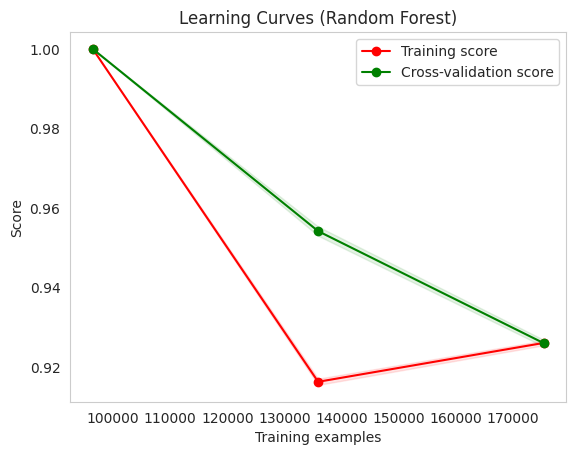

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

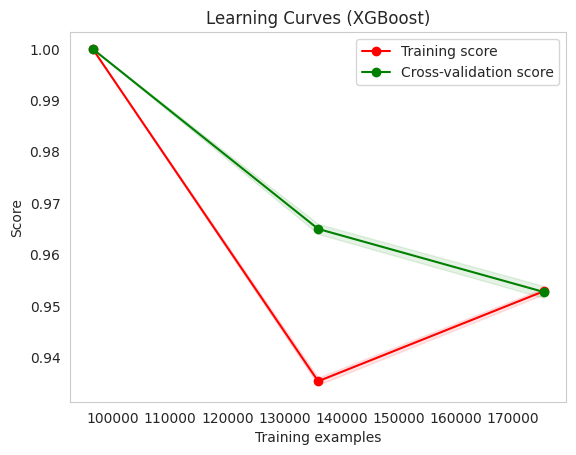

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

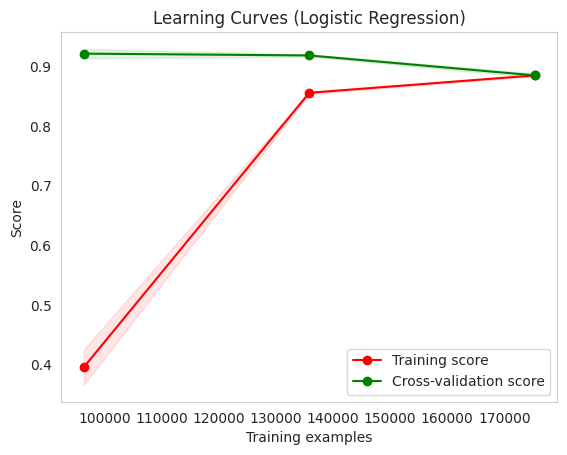

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

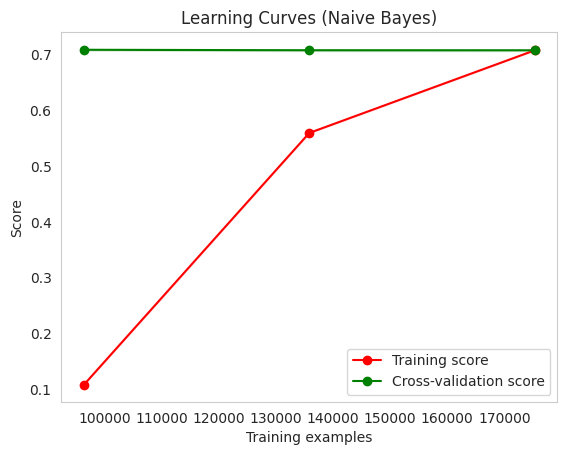

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

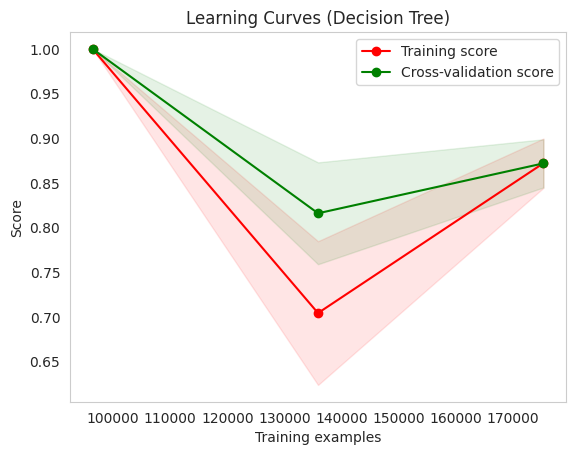

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 17531
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1606
[LightGBM] [Info] Number of data points in the train set: 17531, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the sp

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

[LightGBM] [Info] Number of positive: 4151, number of negative: 92272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5165
[LightGBM] [Info] Number of data points in the train set: 96423, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.043050 -> initscore=-3.101391
[LightGBM] [Info] Start training from score -3.101391


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 43597, number of negative: 92272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050922 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6682
[LightGBM] [Info] Number of data points in the train set: 135869, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.320875 -> initscore=-0.749752
[LightGBM] [Info] Start training from score -0.749752


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 83044, number of negative: 92272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6698
[LightGBM] [Info] Number of data points in the train set: 175316, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473682 -> initscore=-0.105370
[LightGBM] [Info] Start training from score -0.105370


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


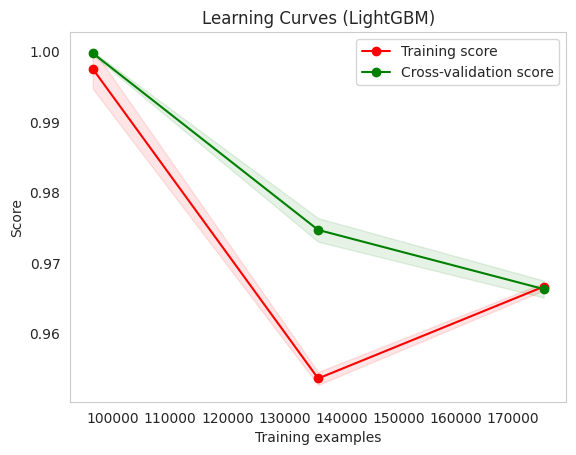

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within [0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be large enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='precision')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt


# Assuming you have your models in a dictionary like this:
models = {
    'Random Forest': rf_classifier,
    'XGBoost': xgb_classifier,
    'Logistic Regression': log_reg_classifier,
    'Naive Bayes': nb_classifier,
    'Decision Tree': dt_classifier,
    'LightGBM': lgb_classifier
}

for name, model in models.items():
    title = f"Learning Curves ({name})"
    plot_learning_curve(model, title, X_train, y_train, cv=5)
    plt.show()